## Access Satellite Wind Altimeter Delayed Qc (Zarr)
This Jupyter notebook demonstrates how to access and plot satellite_wind_altimeter_delayed_qc data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b02b929f-2caf-45d4-ac60-d4632b7ca0ca).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/satellite_wind_altimeter_delayed_qc.ipynb).


In [1]:
dataset_name = "satellite_wind_altimeter_delayed_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 139ms
Checked 201 packages in 1ms


✅ Local version 0.3.16 is up to date (remote: 0.3.16)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4377: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [11]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

2026-05-25 12:01:37,007 - aodn.GetAodn - ERROR - Opening Zarr store s3://aodn-cloud-optimised/satellite_wind_altimeter_delayed_qc.zarr: '.zmetadata'


KeyError: '.zmetadata'

In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	LATITUDE = 5000 ;
	LONGITUDE = 8500 ;
	TIME = 50 ;

variables:
	float32 LATITUDE(LATITUDE) ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float32 LONGITUDE(LONGITUDE) ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:units = degrees_east ;
		LONGITUDE:valid_max = 360.0 ;
		LONGITUDE:valid_min = 0.0 ;
	datetime64[ns] TIME(TIME) ;
		TIME:axis = T ;
		TIME:long_name = time ;
		TIME:standard_name = time ;
		TIME:valid_max = 90000 ;
		TIME:valid_min = 0 ;
	datetime64[ns] TIME_AT(TIME, LATITUDE, LONGITUDE) ;
		TIME_AT:long_name = Time at each along-track observation ;
		TIME_AT:standard_name = time ;
		TIME_AT:

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2017-10-24 00:00:00'), Timestamp('2017-12-12 00:00:00'))

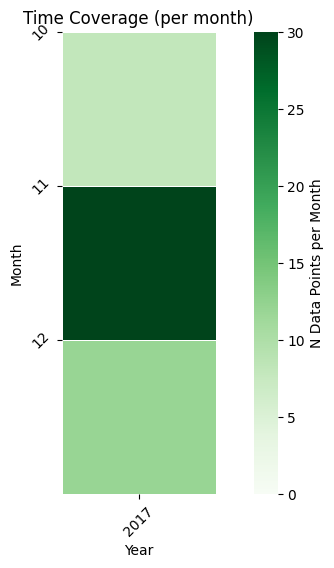

In [7]:
aodn_dataset.plot_time_coverage()

In [8]:
ds

<xarray.Dataset> Size: 102GB
Dimensions:                   (LATITUDE: 5000, LONGITUDE: 8500, TIME: 50)
Coordinates:
  * LATITUDE                  (LATITUDE) float32 20kB -48.99 -48.99 ... 0.995
  * LONGITUDE                 (LONGITUDE) float32 34kB 95.0 95.01 ... 180.0
  * TIME                      (TIME) datetime64[ns] 400B 2017-10-24 ... 2017-...
Data variables:
    TIME_AT                   (TIME, LATITUDE, LONGITUDE) datetime64[ns] 17GB dask.array<chunksize=(20, 2000, 2000), meta=np.ndarray>
    WDIR                      (TIME, LATITUDE, LONGITUDE) float64 17GB dask.array<chunksize=(20, 2000, 2000), meta=np.ndarray>
    WSPD                      (TIME, LATITUDE, LONGITUDE) float64 17GB dask.array<chunksize=(20, 2000, 2000), meta=np.ndarray>
    WSPD_CAL                  (TIME, LATITUDE, LONGITUDE) float64 17GB dask.array<chunksize=(20, 2000, 2000), meta=np.ndarray>
    WSPD_CAL_quality_control  (TIME, LATITUDE, LONGITUDE) float64 17GB dask.array<chunksize=(20, 2000, 2000), meta=np.ndarray>
    WSPD_quality_control      (TIME, LATITUDE, LONGITUDE) float64 17GB dask.array<chunksize=(20, 2000, 2000), meta=np.ndarray>
    filename                  (TIME) object 400B dask.array<chunksize=(20,), meta=np.ndarray>
Attributes: (12/32)
    Conventions:                   CF-1.6,IMOS-1.4
    abstract:                      This dataset contains regularly gridded (0...
    acknowledgement:               Any users of IMOS data are required to cle...
    author:                        Khan, Salman Saeed
    author_email:                  salmansaeed.khan@csiro.au
    cdm_data_type:                 Grid
    ...                            ...
    project:                       Integrated Marine Observing System (IMOS)
    source:                        Sentinel-1 level-2 ocean wind (owi) produc...
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    time_coverage_end:             2017-10-24T23:06:33Z
    time_coverage_start:           2017-10-24T19:58:07Z
    title:                         Daily Sentinel-1 SAR ocean surface winds r...

## Timeseries at a point

In [ ]:
%%time
time_series_df = aodn_dataset.get_timeseries_data(var_name='analysed_sst', 
                                                  lat=-40, 
                                                  lon=130, 
                                                  date_start='2007-12-01', 
                                                  date_end='2009-12-31', 
                                                  lon_name_override="longitude", 
                                                  lat_name_override="latitude").plot_timeseries()

## Plot a gridded variable

2026-05-25 11:55:13,066 - aodn.GetAodn - INFO - Plotting 'SAR wind speed at 10m height assuming neutral marine boundary layer' for 6 time steps.
2026-05-25 11:55:36,129 - aodn.GetAodn - WARNING - No valid data for 2017-10-25 00:00:00, skipping plot.
/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:3754: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


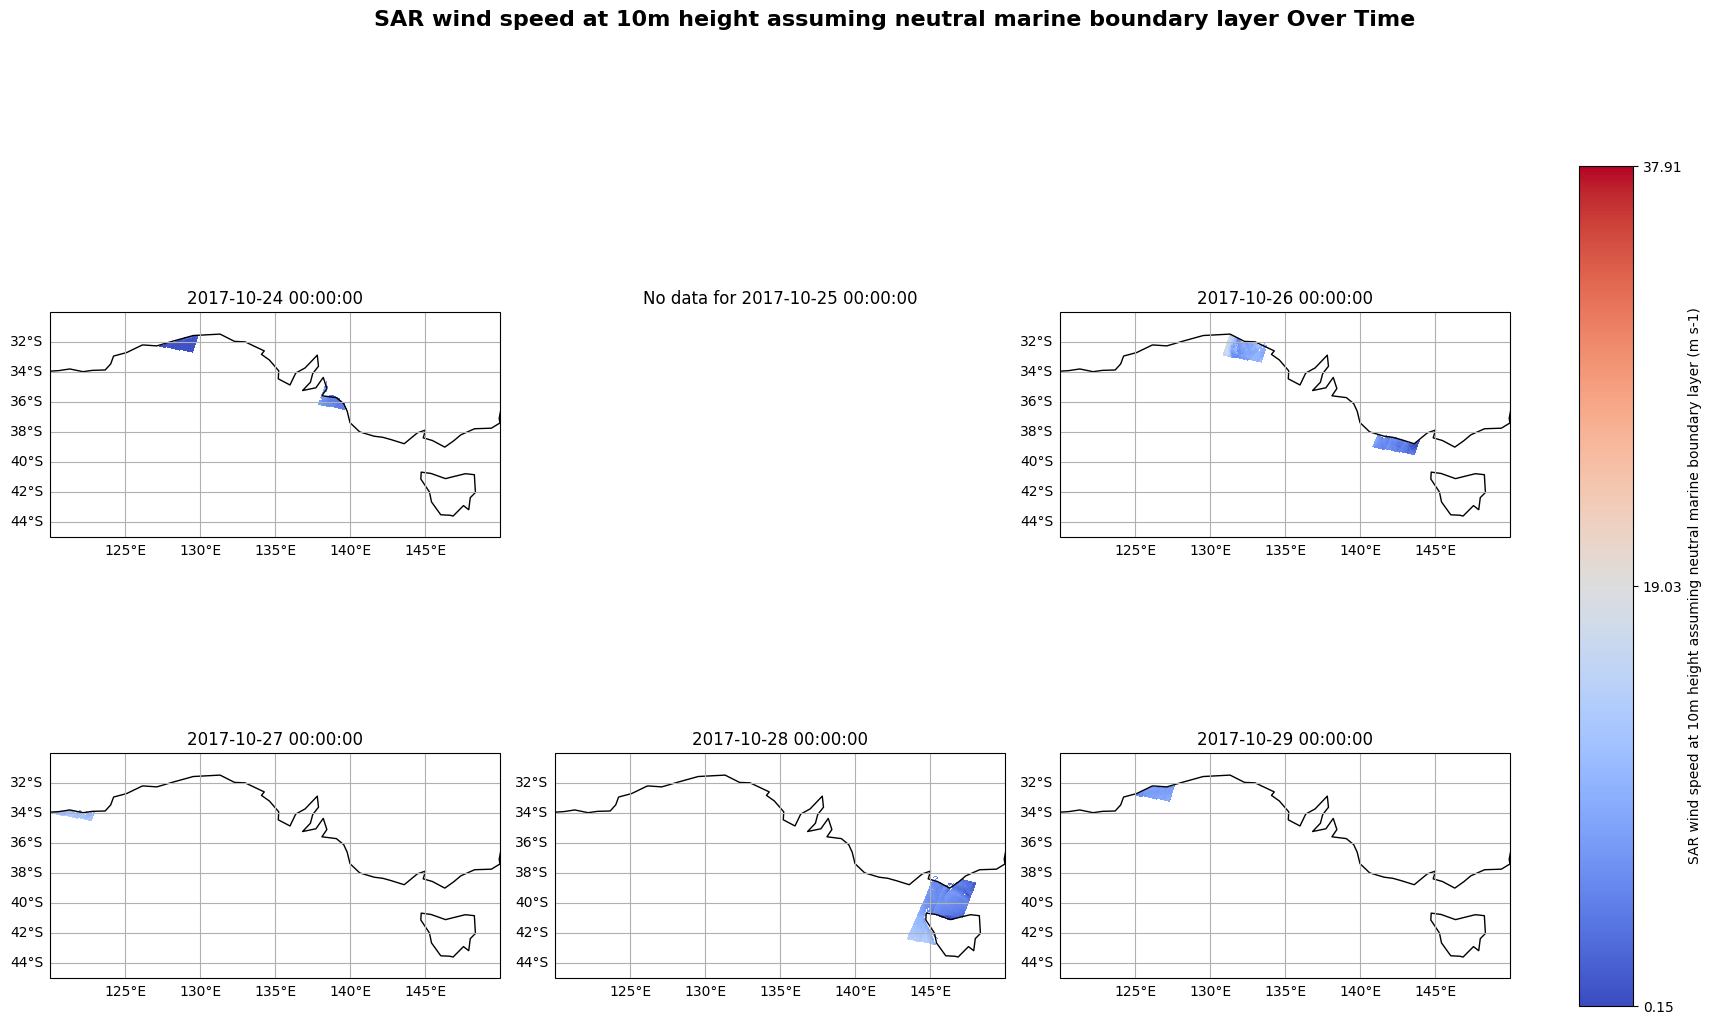

CPU times: user 17.3 s, sys: 47 s, total: 1min 4s
Wall time: 45.9 s


In [10]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='WSPD', 
                                                    date_start='2017-10-10',                                                
                                                    lon_name_override="LONGITUDE", 
                                                    lat_name_override="LATITUDE", 
                                                    lon_slice=(120, 150), 
                                                    lat_slice=(-45, -30), 
                                                    n_days=6, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False)

In [ ]:
%%time
time_series_df = aodn_dataset.plot_gridded_variable(var_name='WDIR', 
                                                    date_start='2017-10-10',                                                
                                                    lon_name_override="LONGITUDE", 
                                                    lat_name_override="LATITUDE", 
                                                    lon_slice=(120, 150), 
                                                    lat_slice=(-45, -30), 
                                                    n_days=6, 
                                                    coastline_resolution="110m", 
                                                    log_scale=False)